In [19]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA = Path('../data').resolve()
palette = {'Default': '#1f77b4', 'TM': '#ff7f0e'}

def parse_name(fname):
    # filename is "<gpu>.<engine>.<task>.csv"; the engine slug can contain
    # dots (e.g. "Qwen3-0.6B"), so split off the first and last segments only.
    stem = fname.rsplit('.csv', 1)[0]
    parts = stem.split('.')
    return parts[0], '.'.join(parts[1:-1]), parts[-1]

def short_engine(slug):
    if 'TMBatchInvariant' in slug:
        return 'TM'
    if 'Default' in slug:
        return 'Default'
    return slug

frames = []
for csv in sorted(DATA.glob('*.csv')):
    gpu, engine_slug, task = parse_name(csv.name)
    d = pd.read_csv(csv)
    d['gpu'] = gpu
    d['task'] = task
    d['engine_slug'] = engine_slug
    d['engine_label'] = short_engine(engine_slug)
    d['token_ids'] = d['completion_token_ids'].map(json.loads)
    frames.append(d)
    print(f'loaded {csv.name}  ({len(d)} rows)')

df = pd.concat(frames, ignore_index=True)

before = len(df)
df = df.drop_duplicates(['engine_label', 'gpu', 'task', 'problem_id', 'batch_size'], keep='first')
if before != len(df):
    print(f'dropped {before - len(df)} duplicate rows')

ENGINES = sorted(df['engine_label'].unique(), key=lambda e: 0 if e == 'Default' else 1)
BS = sorted(df['batch_size'].unique())
PROBLEMS = sorted(df['problem_id'].unique())
print()
print(f'{len(df)} rows | engines={ENGINES} | batch sizes={BS} | {len(PROBLEMS)} problems')
print(f'gpus = {sorted(df["gpu"].unique())}')
print(f'tasks = {sorted(df["task"].unique())}')

loaded NVIDIA_A100-SXM4-40GB.VLLMDefault_Qwen_Qwen3-0.6B.math500.csv  (2523 rows)
loaded NVIDIA_A100-SXM4-40GB.VLLMTMBatchInvariant_Qwen_Qwen3-0.6B.math500.csv  (2500 rows)
dropped 23 duplicate rows

5000 rows | engines=['Default', 'TM'] | batch sizes=[np.int64(1), np.int64(2), np.int64(4), np.int64(8), np.int64(16)] | 500 problems
gpus = ['NVIDIA_A100-SXM4-40GB']
tasks = ['math500']


## Output length distribution

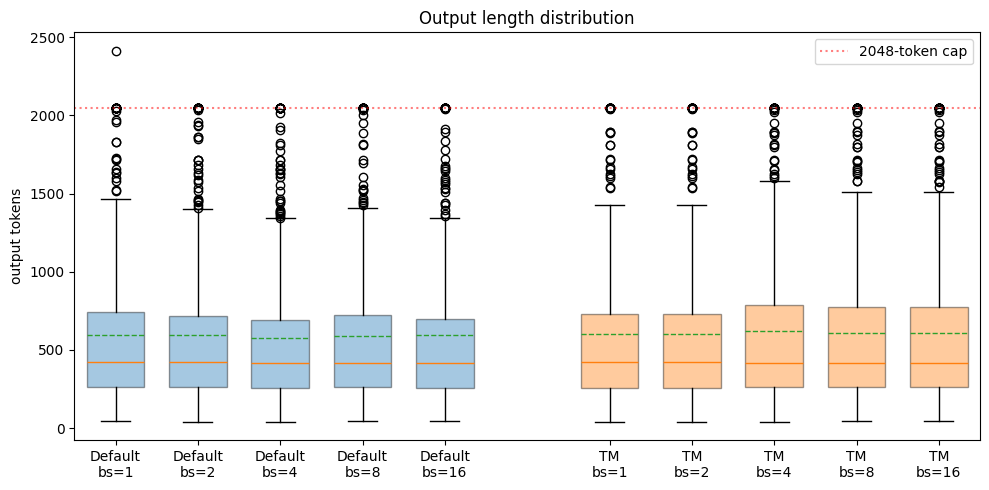

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
data, positions, labels, colors = [], [], [], []
for ei, eng in enumerate(ENGINES):
    for bi, bs in enumerate(BS):
        sub = df[(df['engine_label'] == eng) & (df['batch_size'] == bs)]
        data.append(sub['n_output_tokens'].values)
        positions.append(ei * (len(BS) + 1) + bi)
        labels.append(f'{eng}\nbs={bs}')
        colors.append(palette[eng])

bp = ax.boxplot(data, positions=positions, widths=0.7, patch_artist=True,
                showmeans=True, meanline=True)
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c); patch.set_alpha(0.4)
ax.set_xticks(positions); ax.set_xticklabels(labels)
ax.set_ylabel('output tokens')
ax.axhline(2048, color='red', linestyle=':', alpha=0.5, label='2048-token cap')
ax.set_title('Output length distribution')
ax.legend(loc='upper right')
plt.tight_layout(); plt.show()

## Truncation rate

Completions that hit the 2048-token cap (`finish_reason == 'length'`) are
unfinished and bias any downstream length or accuracy metric. Worth seeing how
many are in that bucket per (engine, batch size).

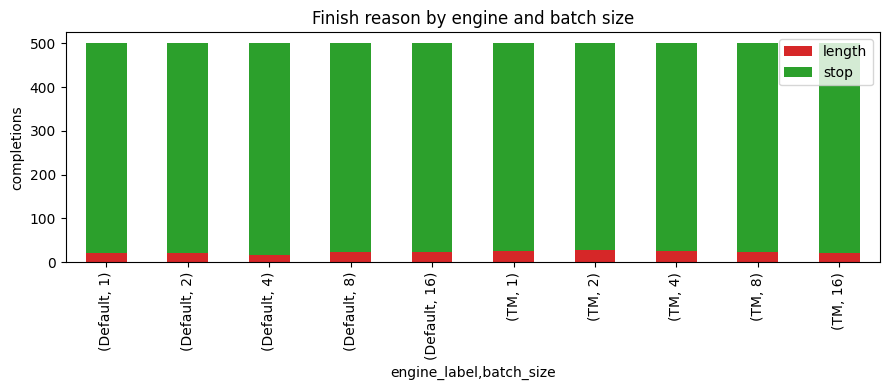

In [21]:
counts = df.groupby(['engine_label', 'batch_size', 'finish_reason']).size().unstack(fill_value=0)
ax = counts.plot(kind='bar', stacked=True, figsize=(9, 4),
                 color={'stop': '#2ca02c', 'length': '#d62728'})
ax.set_ylabel('completions')
ax.set_title('Finish reason by engine and batch size')
ax.legend(title='')
plt.tight_layout(); 
plt.show()

## Token-identity across batch sizes

For each engine and each pair of batch sizes `(a, b)`, the share of problems
where the bs=a completion has *exactly* the same token IDs as the bs=b
completion. The diagonal is 1.0 by definition. Anything off-diagonal below 1.0
is non-invariance.

Below the heatmap: how many of the 500 problems produced identical tokens at
*every* batch size.

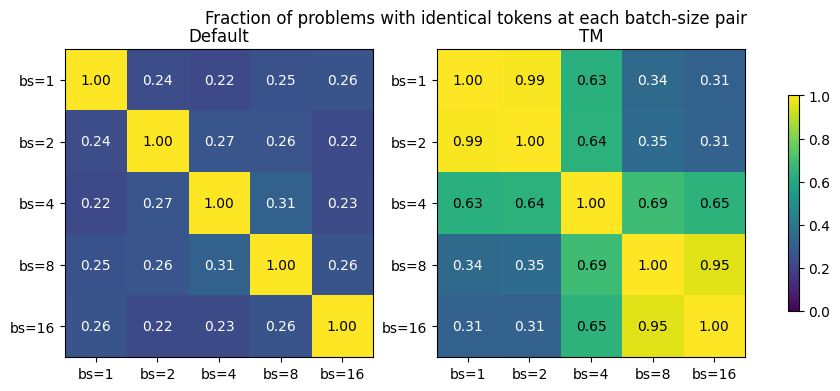

Default: 52/500 problems identical across all batch sizes
TM: 154/500 problems identical across all batch sizes


In [22]:
def pairwise_matrix(eng_df):
    pivot = eng_df.groupby(['problem_id', 'batch_size'])['token_ids'].first().unstack('batch_size')
    bss = sorted(pivot.columns.tolist())
    m = np.zeros((len(bss), len(bss)))
    for i, a in enumerate(bss):
        for j, b in enumerate(bss):
            both = pivot[[a, b]].dropna()
            col_a = both.iloc[:, 0].apply(tuple)
            col_b = both.iloc[:, 1].apply(tuple)
            m[i, j] = (col_a == col_b).mean() if len(both) else float('nan')
    return bss, m

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, eng in zip(axes, ENGINES):
    bss, m = pairwise_matrix(df[df['engine_label'] == eng])
    im = ax.imshow(m, vmin=0, vmax=1, cmap='viridis')
    ax.set_xticks(range(len(bss))); ax.set_xticklabels([f'bs={b}' for b in bss])
    ax.set_yticks(range(len(bss))); ax.set_yticklabels([f'bs={b}' for b in bss])
    for i in range(len(bss)):
        for j in range(len(bss)):
            ax.text(j, i, f'{m[i, j]:.2f}', ha='center', va='center',
                    color='white' if m[i, j] < 0.5 else 'black')
    ax.set_title(eng)
fig.suptitle('Fraction of problems with identical tokens at each batch-size pair')
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.7)
plt.show()

for eng in ENGINES:
    pivot = (df[df['engine_label'] == eng]
             .groupby(['problem_id', 'batch_size'])['token_ids'].first().unstack('batch_size'))
    full = pivot.dropna().apply(lambda r: len({tuple(x) for x in r}) == 1, axis=1)
    print(f'{eng}: {int(full.sum())}/{len(full)} problems identical across all batch sizes')

## Per-problem length stability

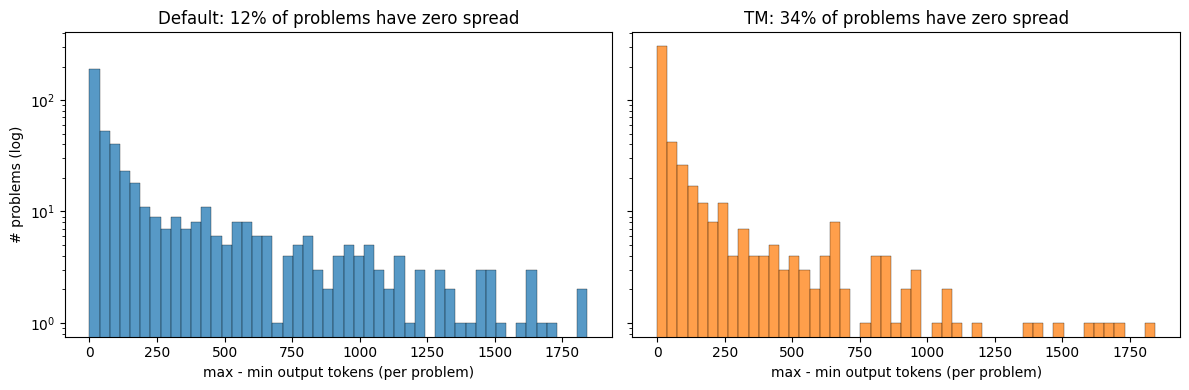

In [23]:
spread = df.groupby(['engine_label', 'problem_id'])['n_output_tokens'].agg(['min', 'max'])
spread['range'] = spread['max'] - spread['min']

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True, sharex=True)
bins = np.linspace(0, max(1, spread['range'].max()) + 1, 50)
for ax, eng in zip(axes, ENGINES):
    vals = spread.xs(eng)['range']
    ax.hist(vals, bins=bins, color=palette[eng], alpha=0.75,
            edgecolor='black', linewidth=0.3)
    ax.set_yscale('log')
    ax.set_xlabel('max - min output tokens (per problem)')
    pct_zero = (vals == 0).mean() * 100
    ax.set_title(f'{eng}: {pct_zero:.0f}% of problems have zero spread')
axes[0].set_ylabel('# problems (log)')
plt.tight_layout(); plt.show()